# 04 Sequence Models

Build leakage-safe sliding windows, train an LSTM with gradient clipping, run walk-forward validation, compare baselines, and inspect temporal importance. `FAST_MODE` limits the classroom run; disable it for the full experiment.

In [1]:
from pathlib import Path
import copy
import random
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = True
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

Device: cuda


## Create a sliding window dataset: for each stock on each day, use the previous 60 days of features as input and the next-day log return as target.

In [2]:


train_df = pd.read_csv(PROCESSED_DIR / "train.csv", parse_dates=["Date"])
val_df = pd.read_csv(PROCESSED_DIR / "val.csv", parse_dates=["Date"])
test_df = pd.read_csv(PROCESSED_DIR / "test.csv", parse_dates=["Date"])

if FAST_MODE:
    demo_tickers = ["AAPL", "MSFT", "JPM", "XOM", "SPY"]
    train_df = train_df[train_df["Ticker"].isin(demo_tickers)].copy()
    val_df = val_df[val_df["Ticker"].isin(demo_tickers)].copy()
    test_df = test_df[test_df["Ticker"].isin(demo_tickers)].copy()

FEATURE_COLS = joblib.load(MODELS_DIR / "feature_cols.joblib")
STEP2_SCALER = joblib.load(MODELS_DIR / "feature_scaler.joblib")
TARGET_COL = "target_next_day_logreturn"

VAL_START = val_df["Date"].min()
TEST_START = test_df["Date"].min()

# Step 2 includes its train boundary in both train and validation.
# Keep each prediction date in only one split here.
train_df = train_df[train_df["Date"] < VAL_START].copy()
val_df = val_df[
    (val_df["Date"] >= VAL_START) &
    (val_df["Date"] < TEST_START)
].copy()
test_df = test_df[test_df["Date"] >= TEST_START].copy()

all_df = (
    pd.concat([train_df, val_df, test_df], ignore_index=True)
      .sort_values(["Ticker", "Date"])
      .drop_duplicates(["Ticker", "Date"], keep="last")
      .reset_index(drop=True)
)

print(f"Feature count: {len(FEATURE_COLS)}")
print(f"Train rows: {len(train_df):,}")
print(f"Validation rows: {len(val_df):,}")
print(f"Test rows: {len(test_df):,}")


def create_sliding_windows(
    df,
    feature_cols,
    target_col,
    sequence_length,
    prediction_start=None,
    prediction_end=None,
    target_must_be_before=None,
):
    X, y, metadata = [], [], []

    for ticker, stock_df in df.groupby("Ticker", sort=False):
        stock_df = stock_df.sort_values("Date").reset_index(drop=True)

        features = stock_df[feature_cols].to_numpy(dtype=np.float32)
        targets = stock_df[target_col].to_numpy(dtype=np.float32)
        dates = pd.to_datetime(stock_df["Date"]).to_numpy()

        # target_next_day_logreturn stored on row i is realized on the
        # next trading day, so record that date explicitly.
        outcome_dates = pd.Series(pd.to_datetime(stock_df["Date"])).shift(-1).to_numpy()

        for i in range(sequence_length - 1, len(stock_df)):
            prediction_date = pd.Timestamp(dates[i])
            outcome_date = (
                pd.Timestamp(outcome_dates[i])
                if not pd.isna(outcome_dates[i])
                else pd.NaT
            )

            if prediction_start is not None and prediction_date < pd.Timestamp(prediction_start):
                continue
            if prediction_end is not None and prediction_date >= pd.Timestamp(prediction_end):
                continue

            # This prevents fold-boundary leakage. For example, the last
            # trading day of month 12 cannot be a training sample when its
            # next-day target is realized in month 13.
            if target_must_be_before is not None:
                boundary = pd.Timestamp(target_must_be_before)
                if pd.isna(outcome_date) or outcome_date >= boundary:
                    continue

            window = features[i - sequence_length + 1:i + 1]
            target = targets[i]

            if not np.isfinite(window).all() or not np.isfinite(target):
                continue

            X.append(window)
            y.append(target)
            metadata.append((ticker, prediction_date))

    if len(X) == 0:
        return (
            np.empty((0, sequence_length, len(feature_cols)), dtype=np.float32),
            np.empty((0,), dtype=np.float32),
            pd.DataFrame(columns=["Ticker", "Date"]),
        )

    return (
        np.stack(X).astype(np.float32),
        np.asarray(y, dtype=np.float32),
        pd.DataFrame(metadata, columns=["Ticker", "Date"]),
    )


class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return self.X[index], self.y[index]


def build_sequence_loaders(sequence_length=60, batch_size=128):
    X_train, y_train, meta_train = create_sliding_windows(
        all_df,
        FEATURE_COLS,
        TARGET_COL,
        sequence_length,
        prediction_end=VAL_START,
        target_must_be_before=VAL_START,
    )

    X_val, y_val, meta_val = create_sliding_windows(
        all_df,
        FEATURE_COLS,
        TARGET_COL,
        sequence_length,
        prediction_start=VAL_START,
        prediction_end=TEST_START,
        target_must_be_before=TEST_START,
    )

    X_test, y_test, meta_test = create_sliding_windows(
        all_df,
        FEATURE_COLS,
        TARGET_COL,
        sequence_length,
        prediction_start=TEST_START,
    )

    train_loader = DataLoader(
        SequenceDataset(X_train, y_train),
        batch_size=batch_size,
        shuffle=True,
    )
    val_loader = DataLoader(
        SequenceDataset(X_val, y_val),
        batch_size=batch_size,
        shuffle=False,
    )
    test_loader = DataLoader(
        SequenceDataset(X_test, y_test),
        batch_size=batch_size,
        shuffle=False,
    )

    return (
        train_loader,
        val_loader,
        test_loader,
        (X_train, y_train, meta_train),
        (X_val, y_val, meta_val),
        (X_test, y_test, meta_test),
    )


SEQUENCE_LENGTH = 60

(
    train_loader_60,
    val_loader_60,
    test_loader_60,
    train_data_60,
    val_data_60,
    test_data_60,
) = build_sequence_loaders(
    sequence_length=SEQUENCE_LENGTH,
    batch_size=128,
)

sample_X, sample_y = next(iter(train_loader_60))

print("Input batch shape:", sample_X.shape)
print("Target batch shape:", sample_y.shape)
print(
    f"60-day sequence samples | "
    f"train={len(train_data_60[1]):,}, "
    f"validation={len(val_data_60[1]):,}, "
    f"test={len(test_data_60[1]):,}"
)


Feature count: 12
Train rows: 17,770
Validation rows: 3,810
Test rows: 3,810


Input batch shape: torch.Size([128, 60, 12])
Target batch shape: torch.Size([128])
60-day sequence samples | train=17,470, validation=3,805, test=3,810


## Define an LSTM model in PyTorch: 2 LSTM layers with 64 hidden units each, dropout=0.3 between layers, a fully connected output layer.

In [3]:
class LSTMRegressor(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        dropout=0.3,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )

        self.output = nn.Linear(hidden_size, 1)

    def forward(self, x):
        sequence_output, _ = self.lstm(x)
        final_time_step = sequence_output[:, -1, :]
        return self.output(final_time_step).squeeze(1)


lstm_model = LSTMRegressor(
    input_size=len(FEATURE_COLS),
    hidden_size=64,
    num_layers=2,
    dropout=0.3,
).to(DEVICE)

print(lstm_model)


LSTMRegressor(
  (lstm): LSTM(12, 64, num_layers=2, batch_first=True, dropout=0.3)
  (output): Linear(in_features=64, out_features=1, bias=True)
)


## Train with Adam optimizer (lr=1e-3), MSE loss, gradient clipping (max_norm=1.0), for 50 epochs with early stopping (patience=7).

Epoch 01 | Train MSE: 0.00112472 | Validation MSE: 0.00051704


Epoch 05 | Train MSE: 0.00033406 | Validation MSE: 0.00049741


Epoch 10 | Train MSE: 0.00032732 | Validation MSE: 0.00050961


Early stopping at epoch 14. Best validation MSE: 0.00049320


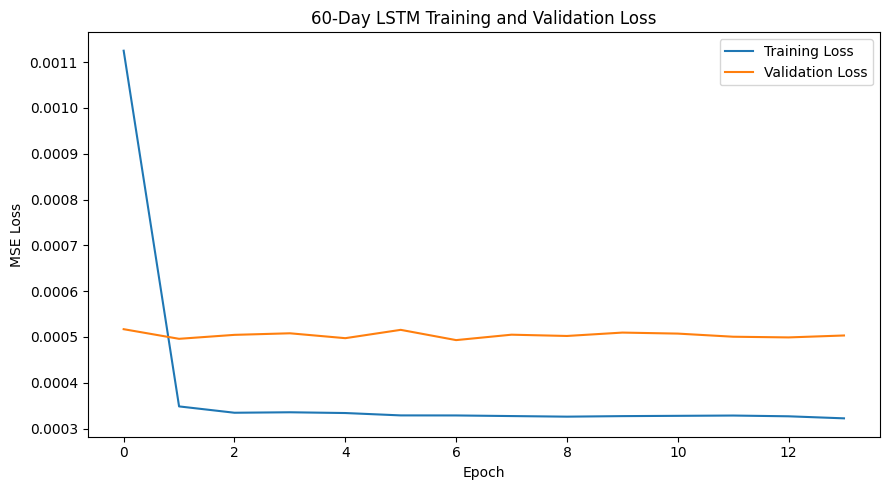

Saved: C:\Users\ashym\Documents\GitHub\jarvis_data_eng_YashMehrotra\ml_2\models\lstm_step4.pt


In [4]:
def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_rows = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            total_loss += loss.item() * len(y_batch)
            total_rows += len(y_batch)

    return total_loss / total_rows


def train_lstm(
    model,
    train_loader,
    val_loader,
    epochs=15 if FAST_MODE else 50,
    patience=4 if FAST_MODE else 7,
    lr=1e-3,
    max_norm=1.0,
    verbose=True,
):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_validation_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        total_train_loss = 0.0
        total_rows = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=max_norm,
            )

            optimizer.step()

            total_train_loss += loss.item() * len(y_batch)
            total_rows += len(y_batch)

        train_loss = total_train_loss / total_rows
        val_loss = evaluate_loss(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_validation_loss:
            best_validation_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if verbose and (epoch == 1 or epoch % 5 == 0):
            print(
                f"Epoch {epoch:02d} | "
                f"Train MSE: {train_loss:.8f} | "
                f"Validation MSE: {val_loss:.8f}"
            )

        if epochs_without_improvement >= patience:
            if verbose:
                print(
                    f"Early stopping at epoch {epoch}. "
                    f"Best validation MSE: {best_validation_loss:.8f}"
                )
            break

    model.load_state_dict(best_state)

    history["best_val_loss"] = best_validation_loss
    history["epochs_ran"] = len(history["train_loss"])

    return model, history


lstm_model, lstm_history = train_lstm(
    model=lstm_model,
    train_loader=train_loader_60,
    val_loader=val_loader_60,
    epochs=50,
    patience=7,
    lr=1e-3,
    max_norm=1.0,
)

plt.figure(figsize=(9, 5))
plt.plot(lstm_history["train_loss"], label="Training Loss")
plt.plot(lstm_history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("60-Day LSTM Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


# Save the actual required Step 4 LSTM for use in Step 5 comparison.
torch.save(
    {
        "model_state_dict": lstm_model.state_dict(),
        "input_size": len(FEATURE_COLS),
        "hidden_size": 64,
        "num_layers": 2,
        "dropout": 0.3,
        "sequence_length": 60,
    },
    MODELS_DIR / "lstm_step4.pt",
)

print("Saved:", MODELS_DIR / "lstm_step4.pt")

## Implement walk-forward validation: train on months 1-12, validate on month 13, then train on months 1-13, validate on month 14, and so on. Report average MSE across all validation months.

In [5]:
# Undo the Step 2 scaling so each fold can fit its own scaler using only
# information available before that fold's validation month.
pretest_scaled = (
    pd.concat([train_df, val_df], ignore_index=True)
      .sort_values(["Ticker", "Date"])
      .drop_duplicates(["Ticker", "Date"], keep="last")
      .reset_index(drop=True)
)

pretest_unscaled = pretest_scaled.copy()
pretest_unscaled[FEATURE_COLS] = STEP2_SCALER.inverse_transform(
    pretest_scaled[FEATURE_COLS]
)

available_months = sorted(
    pretest_unscaled["Date"].dt.to_period("M").unique()
)

walk_forward_results = []

# Fold 1: train months 1-12, validate month 13.
# Fold 2: train months 1-13, validate month 14.
# Continue until every available pre-test month has been used.
validation_months = available_months[12:]
if FAST_MODE:
    validation_months = validation_months[-3:]

for fold_number, validation_month in enumerate(validation_months, start=1):
    validation_start = validation_month.start_time
    validation_end = (validation_month + 1).start_time

    fold_train_raw = pretest_unscaled[
        pretest_unscaled["Date"] < validation_start
    ].copy()

    # Include the validation month only so its feature windows can be built.
    # The scaler is still fit strictly on pre-validation data.
    fold_data_raw = pretest_unscaled[
        pretest_unscaled["Date"] < validation_end
    ].copy()

    fold_scaler = StandardScaler()
    fold_scaler.fit(fold_train_raw[FEATURE_COLS])

    fold_data = fold_data_raw.copy()
    fold_data[FEATURE_COLS] = fold_scaler.transform(
        fold_data_raw[FEATURE_COLS]
    )

    X_train_fold, y_train_fold, _ = create_sliding_windows(
        fold_data,
        FEATURE_COLS,
        TARGET_COL,
        sequence_length=60,
        prediction_end=validation_start,
        target_must_be_before=validation_start,
    )

    X_val_fold, y_val_fold, meta_val_fold = create_sliding_windows(
        fold_data,
        FEATURE_COLS,
        TARGET_COL,
        sequence_length=60,
        prediction_start=validation_start,
        prediction_end=validation_end,
    )

    if len(y_train_fold) == 0 or len(y_val_fold) == 0:
        continue

    train_fold_loader = DataLoader(
        SequenceDataset(X_train_fold, y_train_fold),
        batch_size=128,
        shuffle=True,
    )

    val_fold_loader = DataLoader(
        SequenceDataset(X_val_fold, y_val_fold),
        batch_size=256,
        shuffle=False,
    )

    torch.manual_seed(SEED)

    fold_model = LSTMRegressor(
        input_size=len(FEATURE_COLS),
        hidden_size=64,
        num_layers=2,
        dropout=0.3,
    ).to(DEVICE)

    fold_model, _ = train_lstm(
        model=fold_model,
        train_loader=train_fold_loader,
        val_loader=val_fold_loader,
        epochs=5 if FAST_MODE else 50,
        patience=2 if FAST_MODE else 7,
        lr=1e-3,
        max_norm=1.0,
        verbose=False,
    )

    fold_model.eval()
    fold_predictions = []
    fold_targets = []

    with torch.no_grad():
        for X_batch, y_batch in val_fold_loader:
            fold_predictions.append(
                fold_model(X_batch.to(DEVICE)).cpu().numpy()
            )
            fold_targets.append(y_batch.numpy())

    fold_predictions = np.concatenate(fold_predictions)
    fold_targets = np.concatenate(fold_targets)

    fold_mse = mean_squared_error(
        fold_targets,
        fold_predictions,
    )

    walk_forward_results.append({
        "Fold": fold_number,
        "Training Months": sum(month < validation_month for month in available_months),
        "Validation Month": str(validation_month),
        "MSE": fold_mse,
    })

    print(
        f"Fold {fold_number:03d} | "
        f"training months={sum(month < validation_month for month in available_months)} | "
        f"validate {validation_month} | "
        f"MSE = {fold_mse:.8f}"
    )


walk_forward_df = pd.DataFrame(walk_forward_results)
display(walk_forward_df)

average_walk_forward_mse = walk_forward_df["MSE"].mean()

print(
    f"Average MSE across all "
    f"{len(walk_forward_df)} validation months: "
    f"{average_walk_forward_mse:.8f}"
)


walk_forward_df.to_csv(MODELS_DIR / "step4_walk_forward_metrics.csv", index=False)

Fold 001 | training months=204 | validate 2022-10 | MSE = 0.00056704


Fold 002 | training months=205 | validate 2022-11 | MSE = 0.00046631


Fold 003 | training months=206 | validate 2022-12 | MSE = 0.00017727


,Fold,Training Months,Validation Month,MSE
0,1,204,2022-10,0.000567
1,2,205,2022-11,0.000466
2,3,206,2022-12,0.000177


Average MSE across all 3 validation months: 0.00040354


## Compare LSTM performance against: (a) your feedforward network from Step 3, (b) a simple linear regression. Report MSE, directional accuracy, and Sharpe ratio for all three.

In [6]:
def predict_lstm(model, loader):
    model.eval()
    predictions = []
    targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            predictions.append(
                model(X_batch.to(DEVICE)).cpu().numpy()
            )
            targets.append(y_batch.numpy())

    return np.concatenate(predictions), np.concatenate(targets)


def strategy_sharpe(metadata, actual_returns, predictions):
    result = metadata.copy().reset_index(drop=True)
    result["actual_return"] = np.asarray(actual_returns)
    result["prediction"] = np.asarray(predictions)

    result["strategy_return"] = np.where(
        result["prediction"] > 0,
        result["actual_return"],
        0.0,
    )

    daily_returns = (
        result.groupby("Date")["strategy_return"]
              .mean()
              .sort_index()
    )

    if len(daily_returns) < 2 or daily_returns.std(ddof=1) == 0:
        return np.nan

    return (
        daily_returns.mean() /
        daily_returns.std(ddof=1) *
        np.sqrt(252)
    )


def model_metrics(name, metadata, y_true, y_pred):
    return {
        "Model": name,
        "MSE": mean_squared_error(y_true, y_pred),
        "Directional Accuracy (%)": (
            np.mean(np.sign(y_true) == np.sign(y_pred)) * 100
        ),
        "Sharpe Ratio": strategy_sharpe(
            metadata,
            y_true,
            y_pred,
        ),
    }


# LSTM
lstm_predictions, lstm_targets = predict_lstm(
    lstm_model,
    test_loader_60,
)
test_metadata_60 = test_data_60[2].reset_index(drop=True)

lstm_metrics = model_metrics(
    "LSTM",
    test_metadata_60,
    lstm_targets,
    lstm_predictions,
)


# Evaluate the Step 3 models on exactly the same stock/date endpoints.
aligned_test = (
    test_metadata_60
    .merge(test_df, on=["Ticker", "Date"], how="left")
    .dropna(subset=FEATURE_COLS + [TARGET_COL])
    .reset_index(drop=True)
)

X_test_tabular = aligned_test[FEATURE_COLS].to_numpy(dtype=np.float32)
y_test_tabular = aligned_test[TARGET_COL].to_numpy(dtype=np.float32)
aligned_metadata = aligned_test[["Ticker", "Date"]].copy()


class FeedForwardNN(nn.Module):
    def __init__(self, input_size, hidden_sizes=(128, 64, 32), dropout=0.3):
        super().__init__()

        layers = []
        previous_size = input_size

        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(previous_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            previous_size = hidden_size

        layers.append(nn.Linear(previous_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


feedforward_checkpoint = MODELS_DIR / "feedforward_nn_step3.pt"
linear_checkpoint = MODELS_DIR / "linear_regression_step3.joblib"

if not feedforward_checkpoint.exists() or not linear_checkpoint.exists():
    raise FileNotFoundError(
        "Run 03_feedforward_nn.ipynb first. "
        "Step 4 intentionally loads the actual Step 3 models instead of retraining replacements."
    )

checkpoint = torch.load(
    feedforward_checkpoint,
    map_location=DEVICE,
)

feedforward_model = FeedForwardNN(
    input_size=checkpoint["input_size"],
    hidden_sizes=tuple(checkpoint["hidden_sizes"]),
    dropout=checkpoint["dropout"],
).to(DEVICE)

feedforward_model.load_state_dict(
    checkpoint["model_state_dict"]
)
feedforward_model.eval()

with torch.no_grad():
    feedforward_predictions = (
        feedforward_model(
            torch.tensor(
                X_test_tabular,
                dtype=torch.float32,
                device=DEVICE,
            )
        )
        .squeeze(1)
        .cpu()
        .numpy()
    )

feedforward_metrics = model_metrics(
    "Feedforward NN (Step 3)",
    aligned_metadata,
    y_test_tabular,
    feedforward_predictions,
)


linear_model = joblib.load(linear_checkpoint)
linear_predictions = linear_model.predict(X_test_tabular)

linear_metrics = model_metrics(
    "Linear Regression",
    aligned_metadata,
    y_test_tabular,
    linear_predictions,
)


comparison = pd.DataFrame([
    lstm_metrics,
    feedforward_metrics,
    linear_metrics,
]).set_index("Model")

display(comparison)

,MSE,Directional Accuracy (%),Sharpe Ratio
Model,,,
LSTM,0.000205,51.364829,1.041452
Feedforward NN (Step 3),0.000198,54.566929,1.435800
Linear Regression,0.000198,52.047244,1.262857


## Analyze temporal importance: which days in the 60-day window contribute most? Compute gradient of output with respect to each input time step.

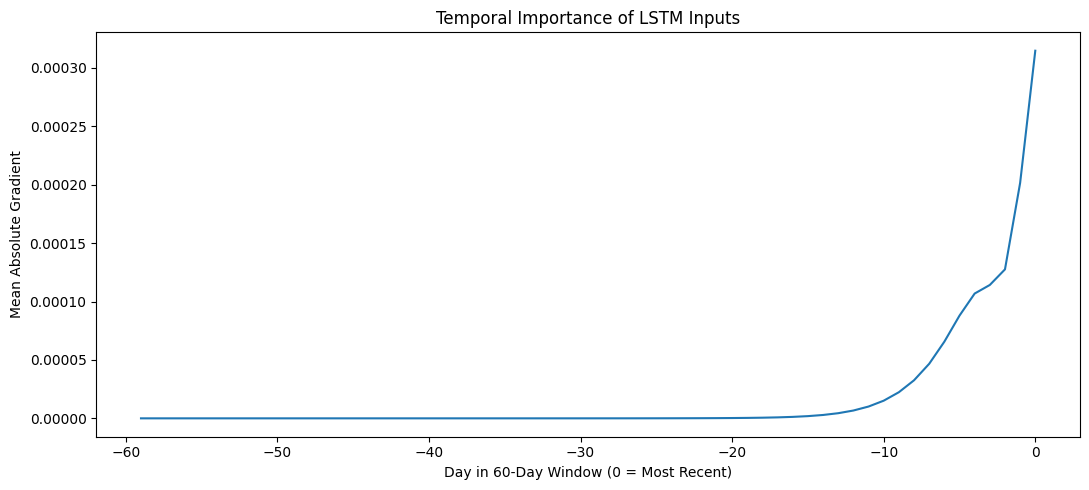

,Relative Day,Mean Absolute Gradient
59,0,0.000315
58,-1,0.000202
57,-2,0.000128
56,-3,0.000114
55,-4,0.000107
54,-5,0.000088
53,-6,0.000066
52,-7,0.000047
51,-8,0.000033
50,-9,0.000022


Most influential days: [0, -1, -2, -3, -4, -5, -6, -7, -8, -9]


In [7]:
lstm_model.eval()

importance_sum = np.zeros(60, dtype=np.float64)
sample_count = 0

for X_batch, _ in test_loader_60:
    X_batch = (
        X_batch.to(DEVICE)
        .clone()
        .detach()
        .requires_grad_(True)
    )

    lstm_model.zero_grad(set_to_none=True)

    # cuDNN does not expose RNN input gradients in eval mode. Disable the
    # cuDNN RNN kernel for this attribution-only forward/backward pass.
    with torch.backends.cudnn.flags(enabled=False):
        predictions = lstm_model(X_batch)
        input_gradients = torch.autograd.grad(
            outputs=predictions.sum(),
            inputs=X_batch,
        )[0]

    # Average absolute gradient across features, then accumulate across samples.
    batch_importance = (
        input_gradients
        .abs()
        .mean(dim=2)
        .detach()
        .cpu()
        .numpy()
    )

    importance_sum += batch_importance.sum(axis=0)
    sample_count += len(X_batch)
    if FAST_MODE and sample_count >= 2_000:
        break


temporal_importance = importance_sum / sample_count
relative_days = np.arange(-59, 1)

importance_df = pd.DataFrame({
    "Relative Day": relative_days,
    "Mean Absolute Gradient": temporal_importance,
})

plt.figure(figsize=(11, 5))
plt.plot(
    importance_df["Relative Day"],
    importance_df["Mean Absolute Gradient"],
)
plt.xlabel("Day in 60-Day Window (0 = Most Recent)")
plt.ylabel("Mean Absolute Gradient")
plt.title("Temporal Importance of LSTM Inputs")
plt.tight_layout()
plt.show()

top_10_days = (
    importance_df
    .sort_values("Mean Absolute Gradient", ascending=False)
    .head(10)
)

display(top_10_days)

print(
    "Most influential days:",
    top_10_days["Relative Day"].tolist(),
)


## Experiment with sequence length: try 20, 40, 60, and 120 days. Which window size gives the best validation performance?

 20-day window | Best validation MSE = 0.00049817


 60-day window | Best validation MSE = 0.00051053


,Sequence Length,Best Validation MSE
0,20,0.000498
1,60,0.000511


Best window size by validation MSE: 20 days


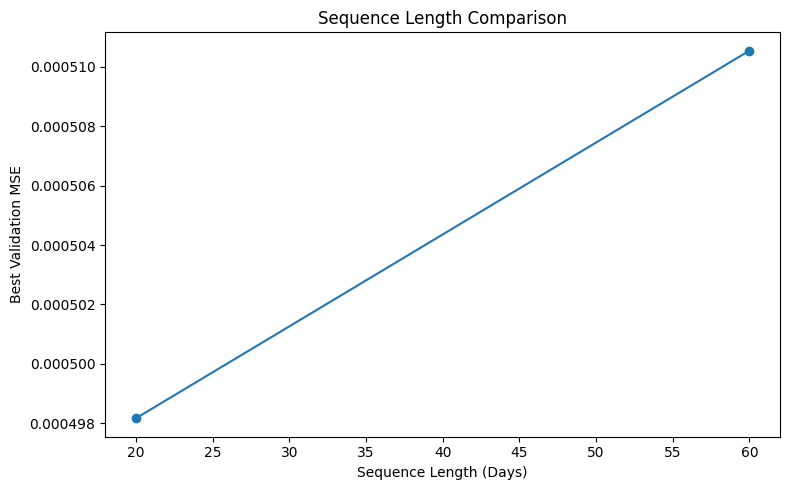

In [8]:
sequence_lengths = [20, 60] if FAST_MODE else [20, 40, 60, 120]
sequence_results = []

for sequence_length in sequence_lengths:
    (
        experiment_train_loader,
        experiment_val_loader,
        _,
        _,
        _,
        _,
    ) = build_sequence_loaders(
        sequence_length=sequence_length,
        batch_size=128,
    )

    # Reset the seed so every window-size experiment starts comparably.
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    experiment_model = LSTMRegressor(
        input_size=len(FEATURE_COLS),
        hidden_size=64,
        num_layers=2,
        dropout=0.3,
    ).to(DEVICE)

    experiment_model, experiment_history = train_lstm(
        model=experiment_model,
        train_loader=experiment_train_loader,
        val_loader=experiment_val_loader,
        epochs=5 if FAST_MODE else 50,
        patience=2 if FAST_MODE else 7,
        lr=1e-3,
        max_norm=1.0,
        verbose=False,
    )

    validation_mse = experiment_history["best_val_loss"]

    sequence_results.append({
        "Sequence Length": sequence_length,
        "Best Validation MSE": validation_mse,
    })

    print(
        f"{sequence_length:3d}-day window | "
        f"Best validation MSE = {validation_mse:.8f}"
    )


sequence_results_df = (
    pd.DataFrame(sequence_results)
      .sort_values("Best Validation MSE")
      .reset_index(drop=True)
)

display(sequence_results_df)

best_sequence_length = int(
    sequence_results_df.iloc[0]["Sequence Length"]
)

print(
    f"Best window size by validation MSE: "
    f"{best_sequence_length} days"
)

plt.figure(figsize=(8, 5))
plt.plot(
    sequence_results_df["Sequence Length"],
    sequence_results_df["Best Validation MSE"],
    marker="o",
)
plt.xlabel("Sequence Length (Days)")
plt.ylabel("Best Validation MSE")
plt.title("Sequence Length Comparison")
plt.tight_layout()
plt.show()